# Intro

In this notebook, we will investigate what learning the generative model of the task could look like. In particular, we will frame learning as inference over possible schedules given observations. First, we will establish theoretical upper bounds on the inference problem from a statistical estimation point of view. Then, we will construct Bayes-optimal posteriors, which can serve as a ground truth when assessing sufficient statistics uncovered by agents trained on the task.

In [4]:
%matplotlib inline

#TODO: majorly refactor this notebook to reflect new modules
import os
import logging
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import polygamma
from itertools import permutations

from foraging import SEED
from foraging.utils.autoreload import setup_auto_reload

# Supress annoying warnings and filter out logs that aren't useful here
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# Set up development tools
setup_auto_reload()
pd.options.mode.copy_on_write = True

# from foraging.plotting import bp, format_yticks, per_block, titler
# from foraging.plotting.belief import (
#     plot_accuracy_across_block,
#     plot_cramer_rao_lb,
#     plot_fisher_info,
#     plot_schedule_beliefs_in_block,
#     plot_schedule_beliefs_mean_and_std_across_block,
# )
from foraging.models._base import HashableDict
from foraging.config.experiments import AngelakiPlottingConfig
from foraging.plotting.belief import BeliefPlotter, plot_fisher_info, plot_cramer_rao_lb
from foraging.utils.belief import compute_accuracy, compute_schedule_posterior
from foraging.utils.data import (
    display_df,
    angelaki_exclusion_criteria,
    filter_df,
    make_angelaki_experiment,
    map_box_positions_to_ranks,
)
from foraging.models.distribution import (
    ExactBayesianUpdateOnProbabilities,
    FactorizedPosterior,
    RewardOutcomeLikelihood,
    RewardIntervalLikelihood,
    Permutation,
    PermutationLikelihood,
    GammaParameters,
    PossibleSchedules,
    Posterior,
    Probabilities,
)
pd.options.mode.copy_on_write = True

# constants
RNG = np.random.default_rng(SEED)
EXPERIMENT_DIR = "../../data/experiments/angelaki"
ANALYSIS_DIR = "../../data/analysis"

✅ Auto-reload extension already loaded!
✅ Auto-reload w/ 2 mode enabled! Changes to all packages will be automatically loaded.


# Load data

The experiment data consists of multiple matfiles corresponding to the data for different subjects. Each matfile contains that subject's push, eye tracking (if available), and position (if available) data organized by blocks and sessions. Each block corresponds to a set of experiment parameters, notably the schedule of each box, the stimulus reliability kappa, and the stimulus type. A hierarchical overview of a given matfile is given in the `Angelaki Data Cleaning` notebook.

In [ ]:
%%capture --no-display
dataset = make_angelaki_experiment(EXPERIMENT_DIR)
dataset = angelaki_exclusion_criteria(dataset, EXPERIMENT_DIR)
dataset = dataset.filter(conds = {"shape": 10})
df = dataset.df
display_df(df, ["subject", "session", "block", "box", "push times", "reward outcomes"])

| subject | session | block | box | push times | reward outcomes |
| --- | --- | --- | --- | --- | --- |
| dylan | 20211206 | 2 | slow | 3.1349999997764826 | False |
| dylan | 20211206 | 2 | fast | 8.464999999850988 | False |
| dylan | 20211206 | 2 | fast | 9.467999999877065 | False |
| dylan | 20211206 | 2 | fast | 11.666999999899417 | False |
| dylan | 20211206 | 2 | medium | 17.125 | False |

# Theoretical Beliefs about the Schedules

In theory, observations about reward carries information about the task parameters that generate them. For example, if the subject is able to perfectly observe the reward intervals $\{t_{\text{reward}}\}$, which is the time that needs to elapse before reward becomes available, then they can average these reward intervals to get an estimate of the box's schedule $\lambda$, the mean of the generative distribution. It is known that the sample mean of observations drawn from a Gaussian distribution is the most efficient estimator of the population mean, in the sense that the variance achieves the Cramer-Rao lower bound. The same is true for the sample mean of observations drawn from a gamma distribution, which is the distribution we use in the experiment to generate reward intervals.

Now, in the actual experiment, the rewards are hidden when they become available and the subject only receives potentially noisy observations of the reward interval. The observations take the form of a color cue that encodes the reward interval with some spatiotemporal noise. On one end of the spectrum lie completely unreliable observations that offer no information about the reward intervals, and hence no information about the schedules that generated them; however, there is still hope in the form of censored observations made available when the subject decides to push at the box. Then, the subject observes whether reward was available by the time they pushed at $t_{\text{push}}$, and they can use this observation to update their beliefs about the schedules. For example, if the subject waits a long time at a box they believe to be fast but still does not observe reward when they push, that is an indication that the box may be slower than anticipated, and vice versa if the subject only waits a short time at a box they thought was slow and is pleasantly surprised to receive reward. Both the perfect observations and the censored observations correspond to distinct but related likelihood functions, defined below:

*Perfect Observations*

$$
L(\lambda) = f(t_{\text{reward}}|\lambda, \alpha)
$$

*Censored Observations*

$$
L(\lambda) = \begin{cases}
F(t_{\text{push}} | \lambda, \alpha) & \text{if reward }\\
1 - F(t_{\text{push}} | \lambda, \alpha) & \text{else}
\end{cases}
$$

where $f$ and $F$ are the pdf and cdf of the gamma distribution, respectively, and $\alpha$ denotes the shape parameter, which we assume to be known $^1$. From these, we can derive lower bounds on how fast the uncertainty can shrink for the ideal observer. Assuming a continuous hypothesis space over possible schedules, and independence between boxes, one way to do this is to derive the Fisher information, which we go into next section.

## Fisher Information

The Fisher information tells us how discriminable the task parameters, such as the schedules $\{\lambda_i\}$, of the experiment are from similar parameters-- the higher the Fisher information, the higher the theoretical limit on our knowledge or certainty about the parameters. This relationship is formally known as the Cramer-Rao lower bound, which states that the variance of any unbiased estimator can be no lower than the inverse Fisher information. Assuming the shape parameter $\alpha$ is known, the Fisher information of perfect and censored obserations is given below:

*Perfect Observations*

$$J(\lambda) = \frac{\alpha}{\lambda^2}$$

*Censored Observations*

$$J(\lambda) = (\frac{t_{\text{push}}}{\lambda})^2 \frac{f^2(t_{\text{push}}|\lambda, \alpha)}{F(t_{\text{push}}|\lambda, \alpha)(1-F(t_{\text{push}}|\lambda, \alpha))}$$

Notice that the Fisher information of the censored observations depends on the push time $t_{\text{push}}$. Intuitively, this is because if you wait too long to push relative to the schedule or go too soon, then on average you will get very little information. Only a moderate regime of wait times gives useful information, and each box has a different optimal wait time that delivers maximum Fisher information. These curves are shown below.

$^1$ The shape parameter basically influences the variance of the reward intervals and is held constant across blocks as well as shared between boxes. At the end of this notebook, we derive the Cramer-Rao lower bound for the shape parameter and show that it virtually vanishes to 0 after accumulating a typical block's worth of observations, validating our assumption that the subjects SHOULD know the shape parameter to a high degree of confidence.

Optimal Fisher info for schedule 7 with shape = 10 occurs at t = 7.4097, with value 0.1303
Optimal Fisher info for schedule 14 with shape = 10 occurs at t = 14.8195, with value 0.0326
Optimal Fisher info for schedule 21 with shape = 10 occurs at t = 22.2292, with value 0.0145


<Axes: title={'center': 'Fisher information of Reward Observations'}, xlabel='push time (s)', ylabel='Fisher information'>

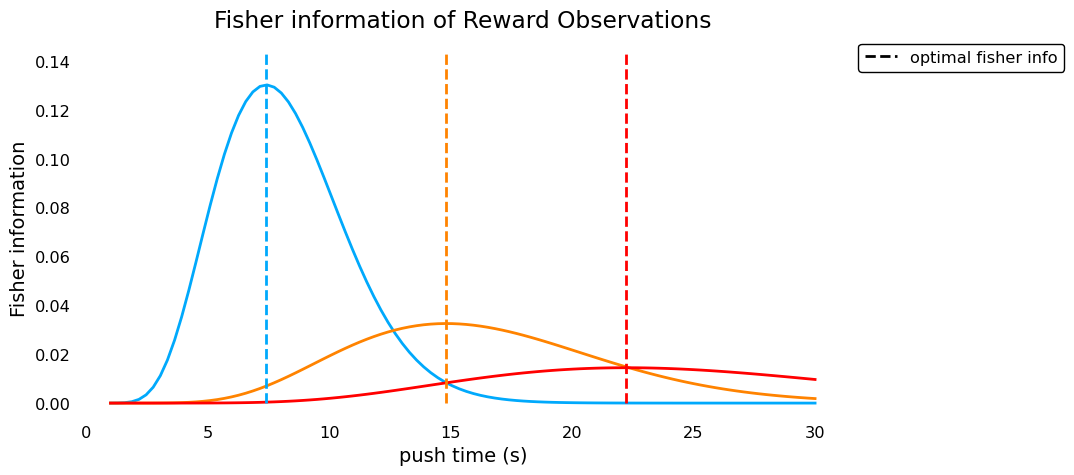

In [67]:
plot_fisher_info(
    np.linspace(1, 30, 100),
    schedules=[7, 14, 21],
    alpha=10,
    title="Fisher information of Reward Observations",
    palette = AngelakiPlottingConfig().PALETTE
)

The optimal wait times that maximize the Fisher information of each box occur at distinct timepoints ordered by schedules. Notice that the maximal Fisher information of the two slower boxes are close together in value compared to the fast box, suggesting that the fast box may be easiest to figure out first because it only needs faster and fewer pushes to reach a certain precision. Using the maximal Fisher information of each box, we show how the uncertainty shrinks with more observations by showing how the standard deviation, the square root of the Cramer-Rao lower bound, decreases with the number of obervations. We also do the same for perfect observations and compare both types of observations.

<Axes: title={'center': 'Cramer-Rao Lower Bound as a Function of # Observations'}, xlabel='# observations', ylabel='standard deviation'>

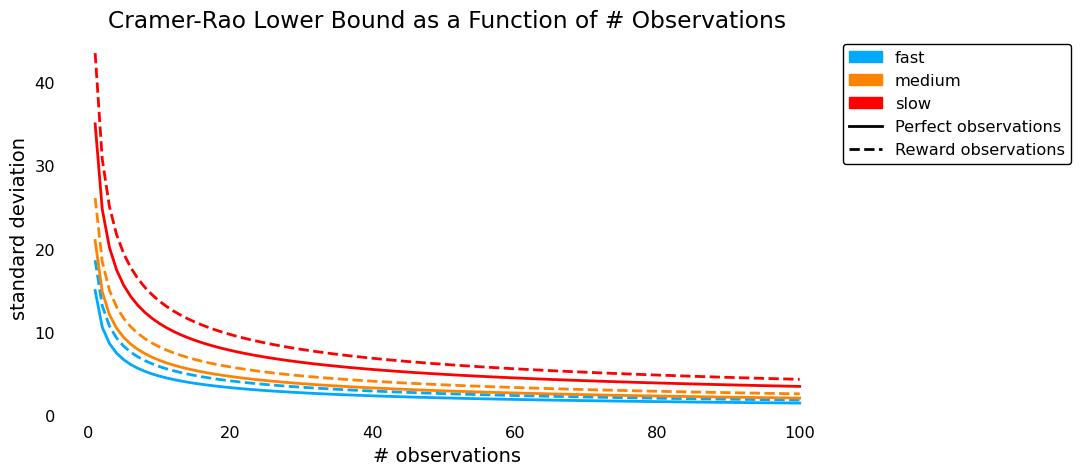

In [7]:
plot_cramer_rao_lb(n=100, schedules=[15, 21, 35], alpha=1, palette = AngelakiPlottingConfig().PALETTE)

After 50 pushes, all schedules can be estimated within ±1-2 s $^2$. Notice the striking similarity between both types of observations! Having perfect observations only marginally improves the efficiency of the inference process. This provides this tired grad student an excuse to neglect incorporating color observations into the Bayesian model...
#TODO: actually, if pushing so fast s.t. reward outcomes provide little information, color observations may provide a lot of information in shorter amount of time. Show above plot but for some short fixed push interval instead (then argue that actual behavior is consistent with infomaxing pushes, so in that case you are not getting much more information from color)

$^2$ Note that these results are shown for shape parameter = 10; when shape = 1, it takes 3-4x longer to achieve the same precision.

## Empirical Beliefs using Censored Observations

Given real behavioral data, we can construct Bayes-optimal beliefs about the schedules using censored observations when the color cue is completely unreliable. These beliefs take the form of a posterior over possible schedules, and they are updated according to Bayes rule:

$$b(\lambda|o_n := t_{\text{push}}) \propto \begin{cases} F(t_{\text{push}} | \lambda)b(\lambda|o_{1:n-1}) & \text{if reward}\\ (1-F(t_{\text{push}} | \lambda))b(\lambda|o_{1:n-1}) &  \text{else}\end{cases}$$

Assuming a uniform prior over possible schedules that resets between blocks, the maximum a posteriori (MAP) estimator is equivalent to the maximum likelihood estimator (MLE). An example posterior over one block is shown below. Inferring the actual prior is an inverse problem that we leave for downstream analysis.

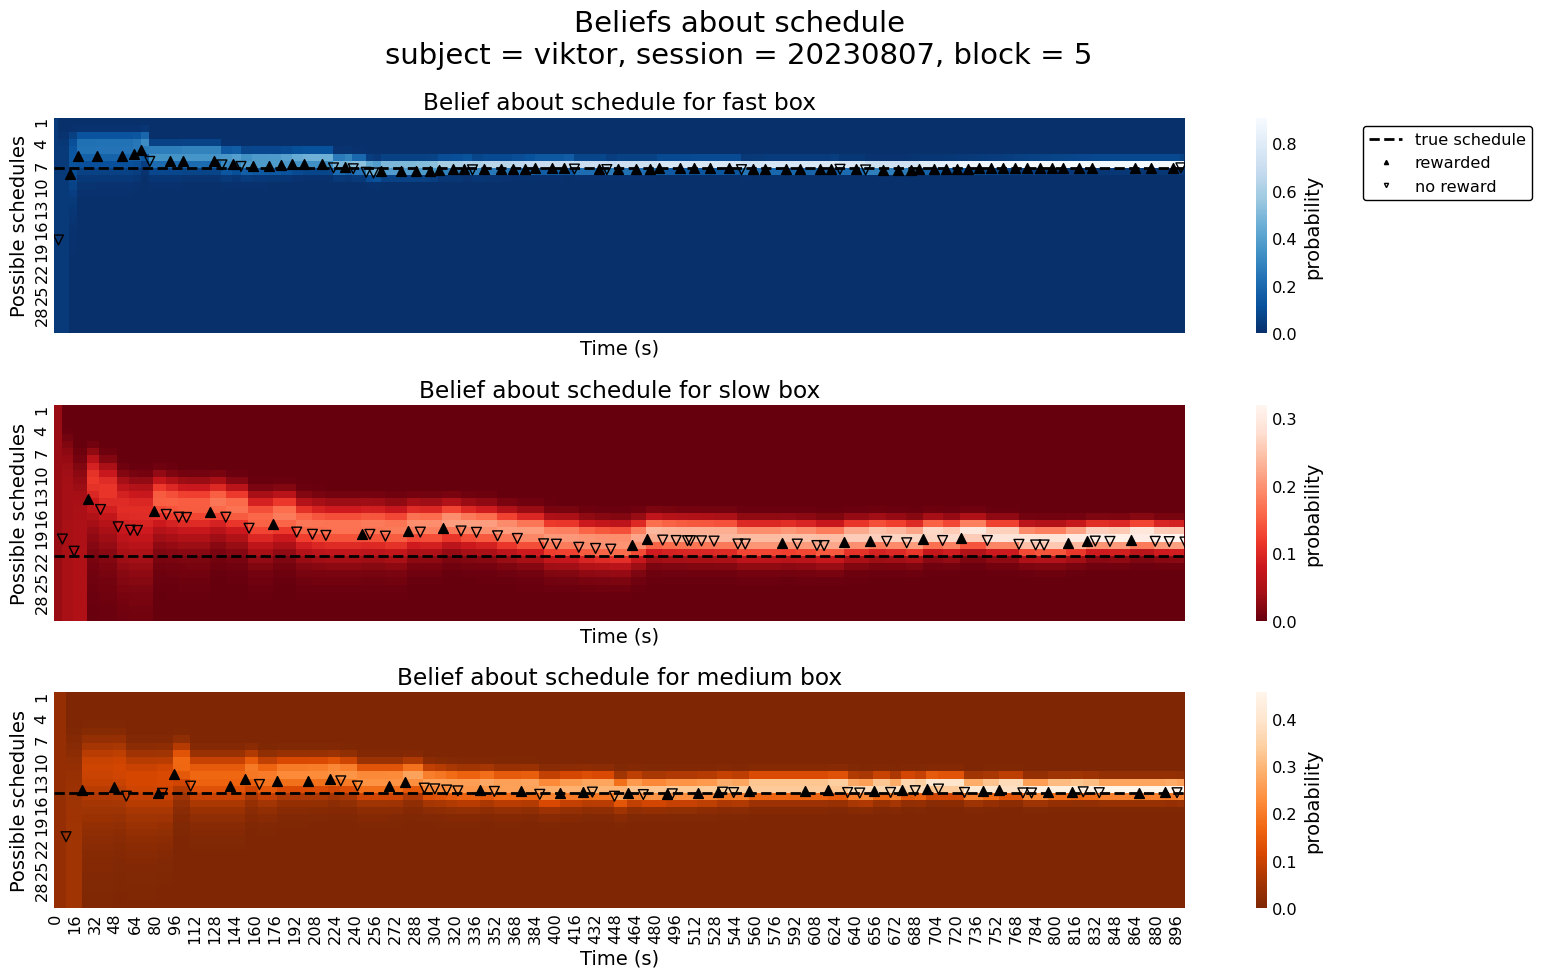

In [43]:
schedule_candidates = np.arange(30) + 1
belief_update = ExactBayesianUpdateOnProbabilities(RewardOutcomeLikelihood(), vectorize=True)

def posterior_maker(dataset, block_key, block) -> FactorizedPosterior:
    shape = block.index.unique("shape")[0]
    n_boxes = block["n boxes"].values[0]
    uniform = 1 / len(schedule_candidates) * np.ones(len(schedule_candidates))
    single_box_prior = Probabilities(
        support=PossibleSchedules(schedule=schedule_candidates, shape=shape),
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return FactorizedPosterior(
        n_boxes, new_key, belief_update, prior=single_box_prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_posterior, posterior_maker = posterior_maker)
plotter = BeliefPlotter(schedule_beliefs, dataset, AngelakiPlottingConfig().to_dict())
plotter.plot_schedule_beliefs_in_block(conds = dict(subject="viktor", session=20230807, block=5));

Now we will aggregate posteriors over blocks and report the average summary statistics of those posteriors.

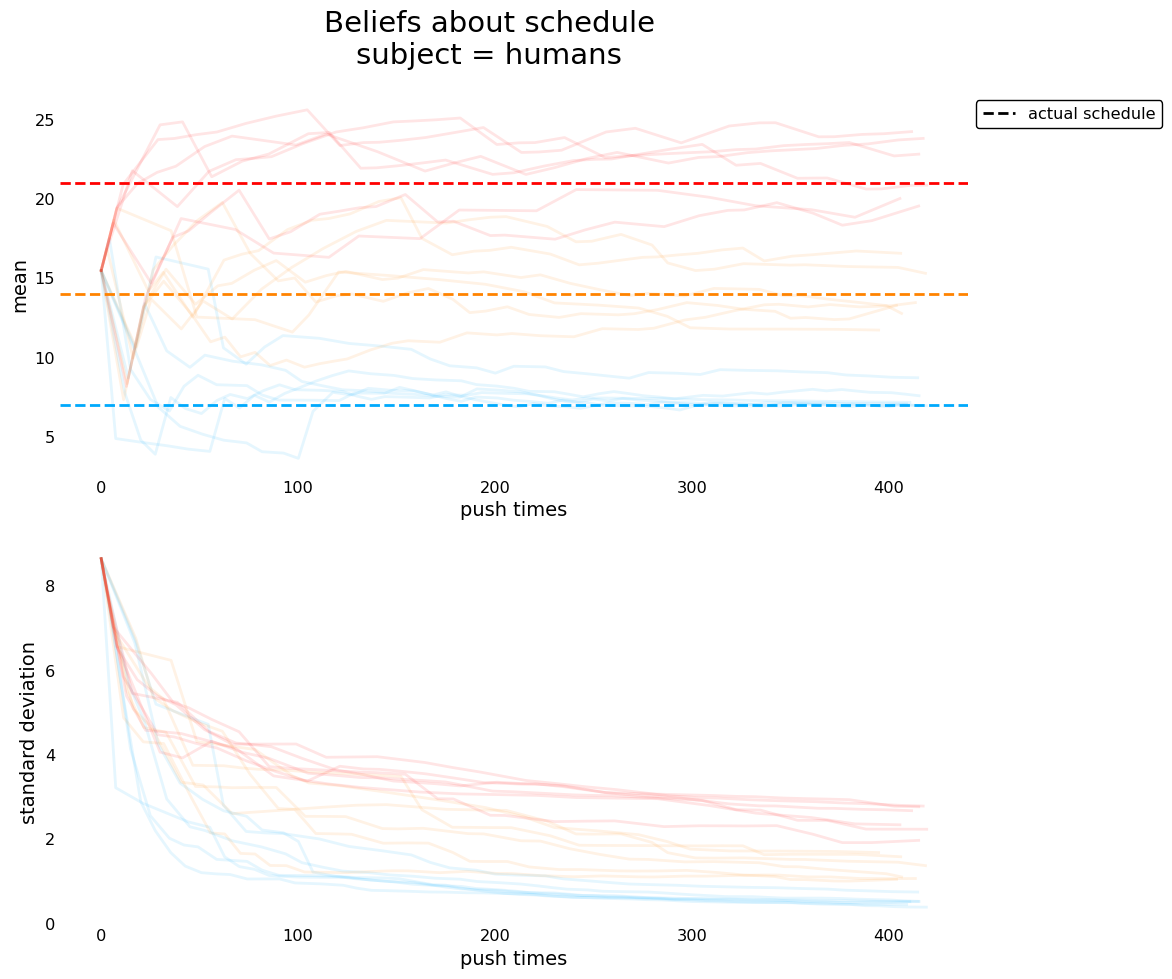

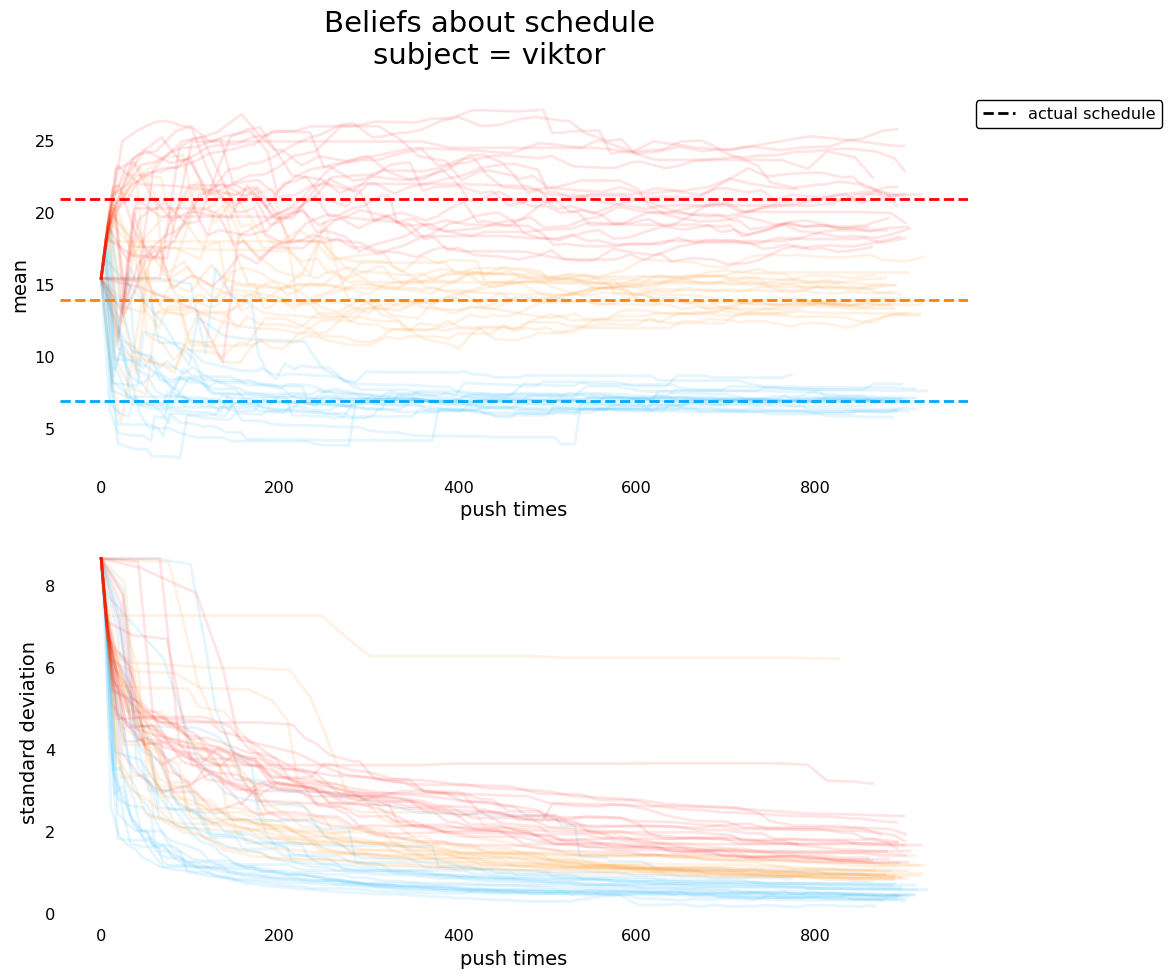

In [9]:
plotter.plot_schedule_beliefs_mean_and_std_across_block(
    conds={"kappa": 0, "shape": 10},
    x="push times",
    show_traces=True,
    show_average = False
);

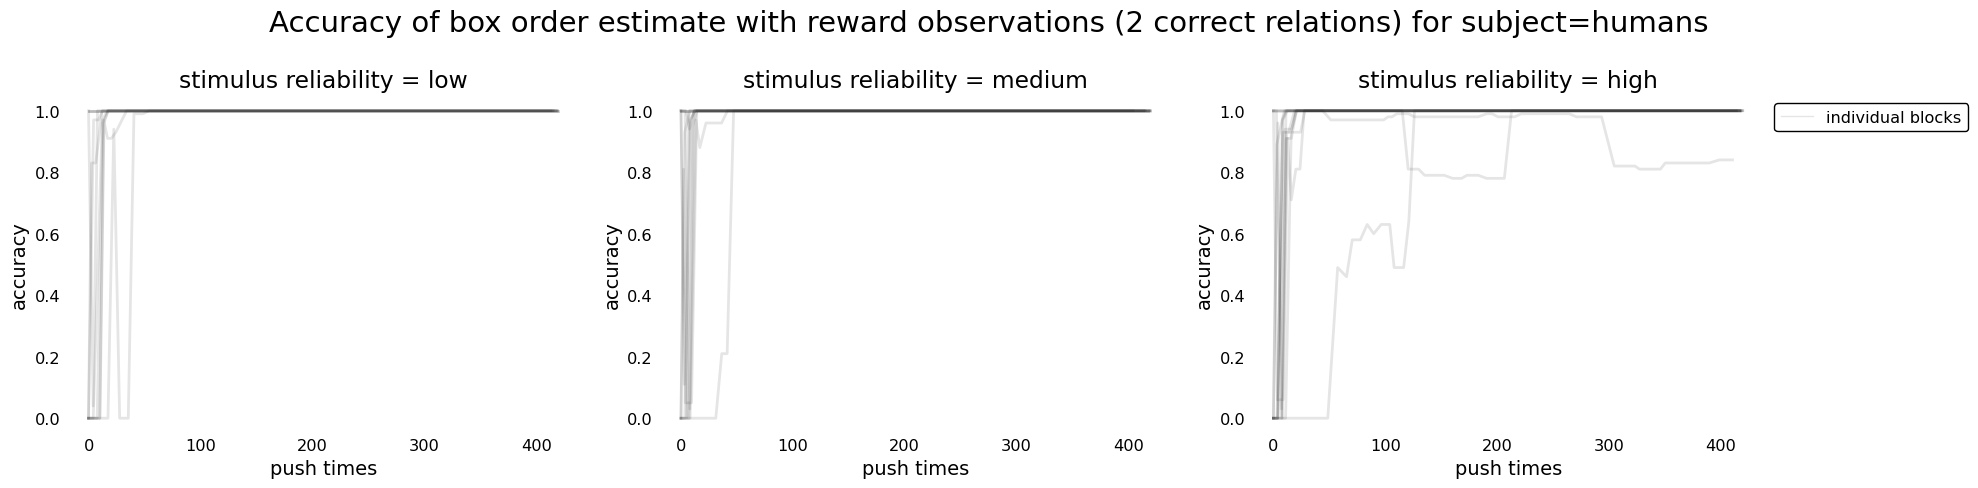

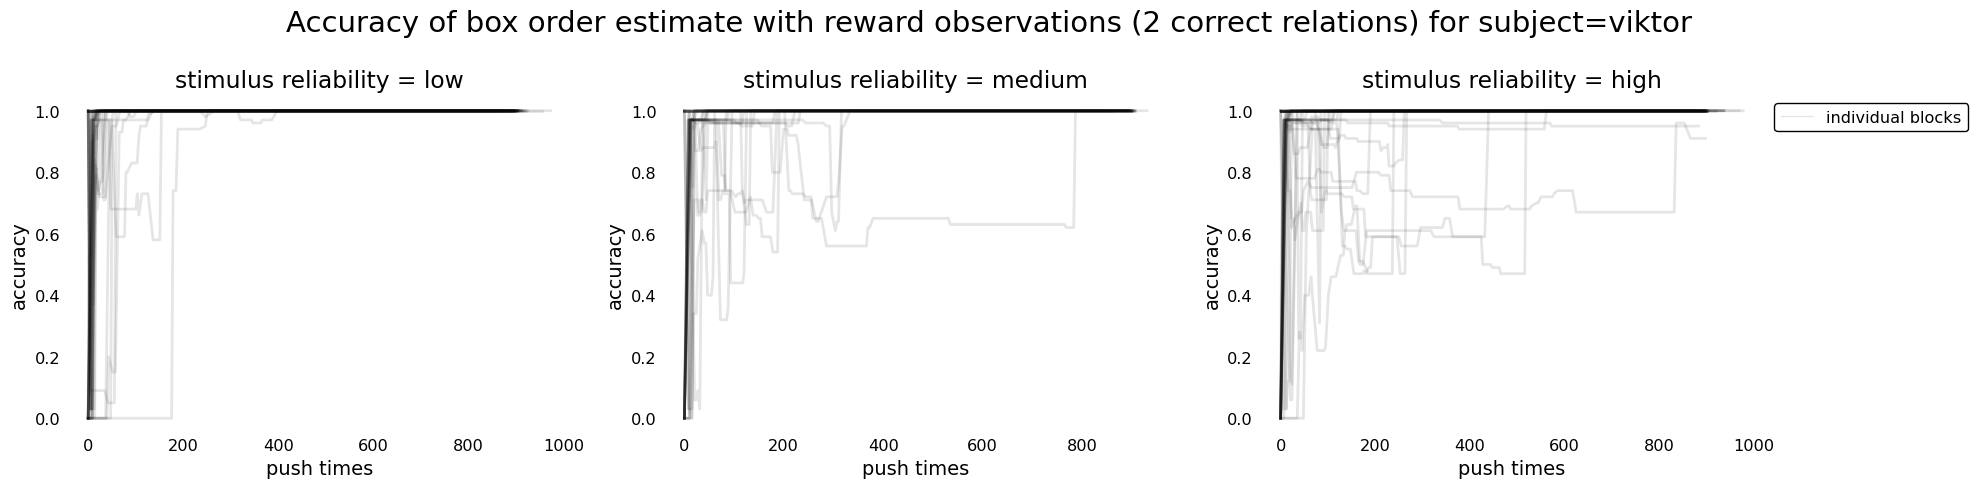

In [62]:
n_correct = 2
accuracies, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs, n_correct = n_correct)
plotter.plot_conditions_by_subject(
    plotter.plot_accuracy_across_block, 
    accuracies = accuracies,
    col_condition = 'stimulus reliability',
    x="push times",
    show_traces=True,
    show_average = False,
    color="black",       
    fig_title=f'Accuracy of box order estimate with reward observations ({n_correct} correct relations)' 
);

In [55]:
# sampled_orders = np.array([[[1,2],[0,1],[2,0]],[[2,2],[0,1],[1,0]]])
# true_order = np.array([2,0,1])
# true_rel = true_order[:, None] < true_order[None, :]
# sampled_rel = sampled_orders[:, :, None, :] < sampled_orders[:, None, :, :]
# true_rel = true_order[:, None] < true_order[None, :]  # (boxes, boxes)
# pair_mask = np.triu(np.ones((3, 3), dtype=bool), 1)
# correct_counts = ((sampled_rel == true_rel[None, :, None, :]) & pair_mask[None, :, None, :]).sum(axis=(1, 3))
# accuracies = (correct_counts >= 1).mean(axis=1)

sampled_orders = np.array([[[0,0],[1,1],[2,2]],[[2,2],[0,1],[1,0]]])
true_order = np.array([2,0,1])

true_rel = true_order[:, None] < true_order[None, :]                # (boxes, boxes)
sampled_rel = sampled_orders[:, :, None, :] < sampled_orders[:, None, :, :]  # (steps, boxes, boxes, samples)

pair_mask = np.triu(np.ones(true_rel.shape, dtype=bool), 1)         # (boxes, boxes)

# count correct relations per (step, sample)
correct_counts = ((sampled_rel == true_rel[None, :, :, None]) & pair_mask[None, :, :, None]).sum(axis=(1, 2))  # (steps, samples)

n_correct = 2
accuracies = (correct_counts >= n_correct).mean(axis=1)     
accuracies        # (steps,)

array([0., 1.])

In [41]:
import numpy as np

# accuracies: dict[HashableDict (or tuple), ArrayLike]
worst_key, worst_max = None, np.inf

for key, acc in accuracies.items():
    acc = np.asarray(acc, dtype=float)
    # m = np.nanmax(acc)  # use max(acc) if you know there are no NaNs
    m = acc[-1]
    if m < worst_max:
        worst_max = m
        worst_key = key

print("block with lowest max accuracy:", worst_key)
print("that block's max accuracy:", worst_max)

block with lowest max accuracy: {'subject': 'humans', 'session': np.int64(3), 'block': np.int64(8)}
that block's max accuracy: 0.06


In [ ]:
#TODO: accuracy based on exact ordering may be harsh, also consider like panos did getting 3 order relations right vs 2 vs 1 vs 0. i would just repeat the same accuracy plots but for different degrees of accuracy

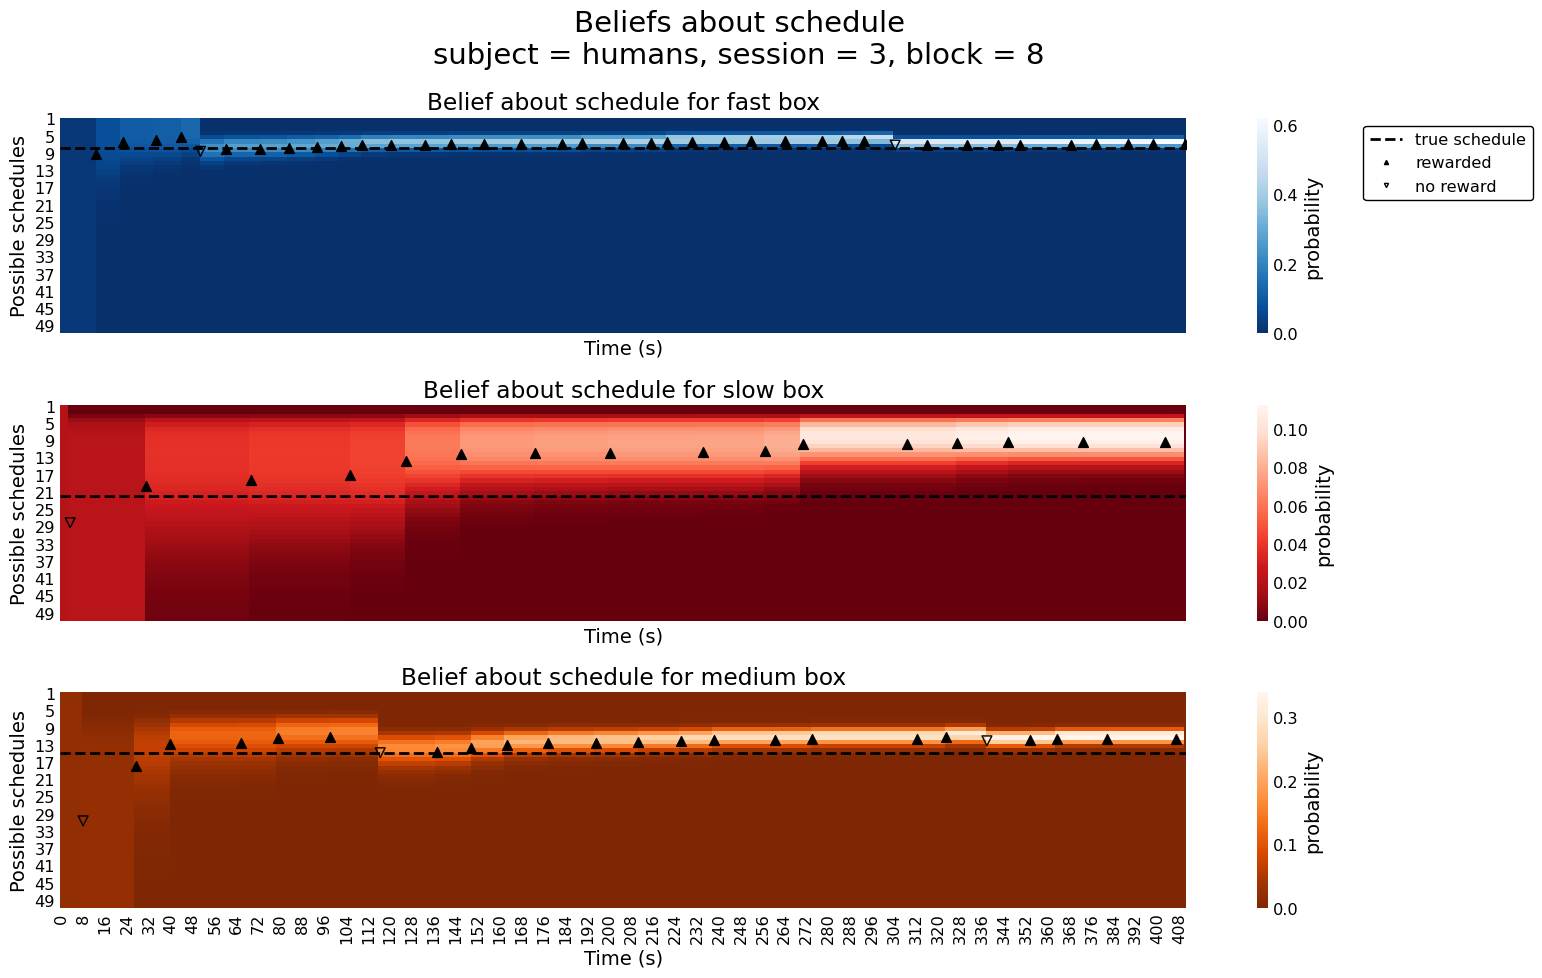

In [42]:
plotter.plot_schedule_beliefs_in_block(conds = dict(subject="humans", session=3, block=8));

Maybe somewhat paradoxically, when the stimulus reliability increases, the accuracy of the beliefs seems to go down! Now why might that be? When the animal's pushes become more accurate, they are getting more rewarded observations, which biases their estimates of the schedules to be faster! The likelihood does not take into account the extra information the color observations provide. Now compare to the accuracy when we assume the subject makes perfect observations of the reward interval.

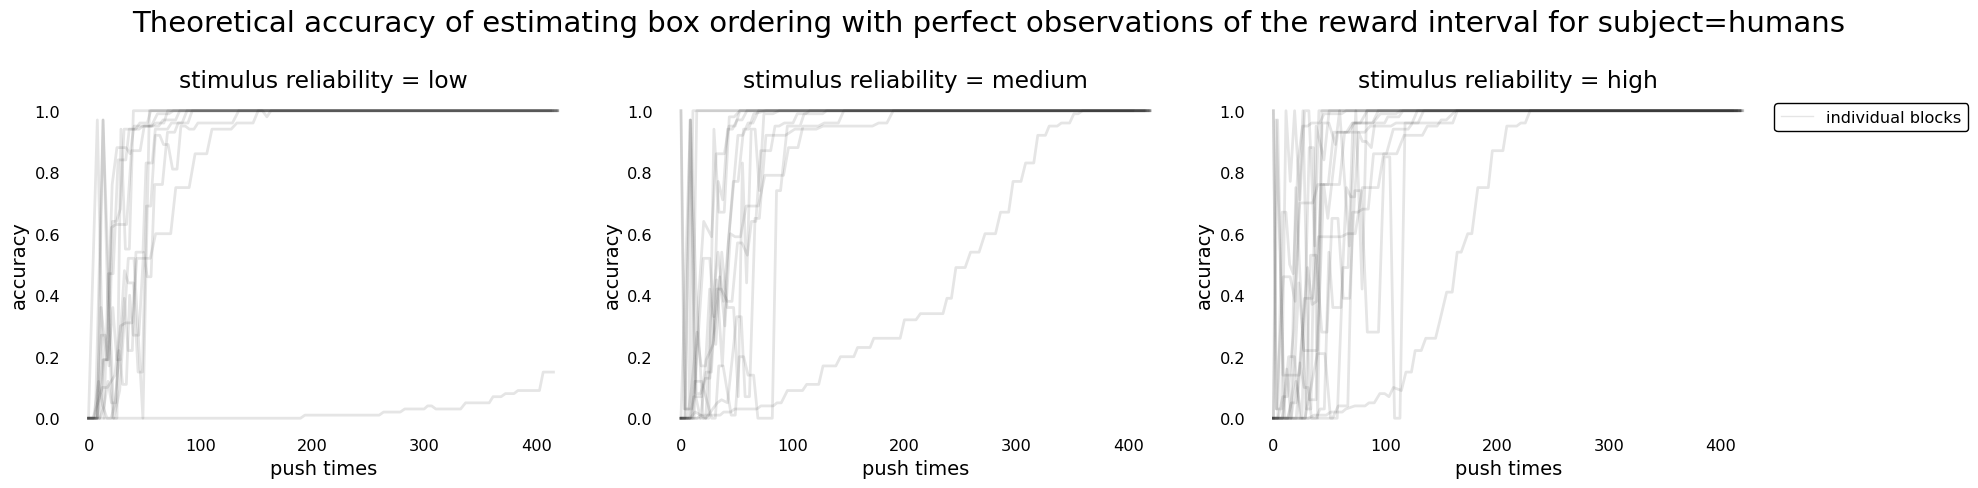

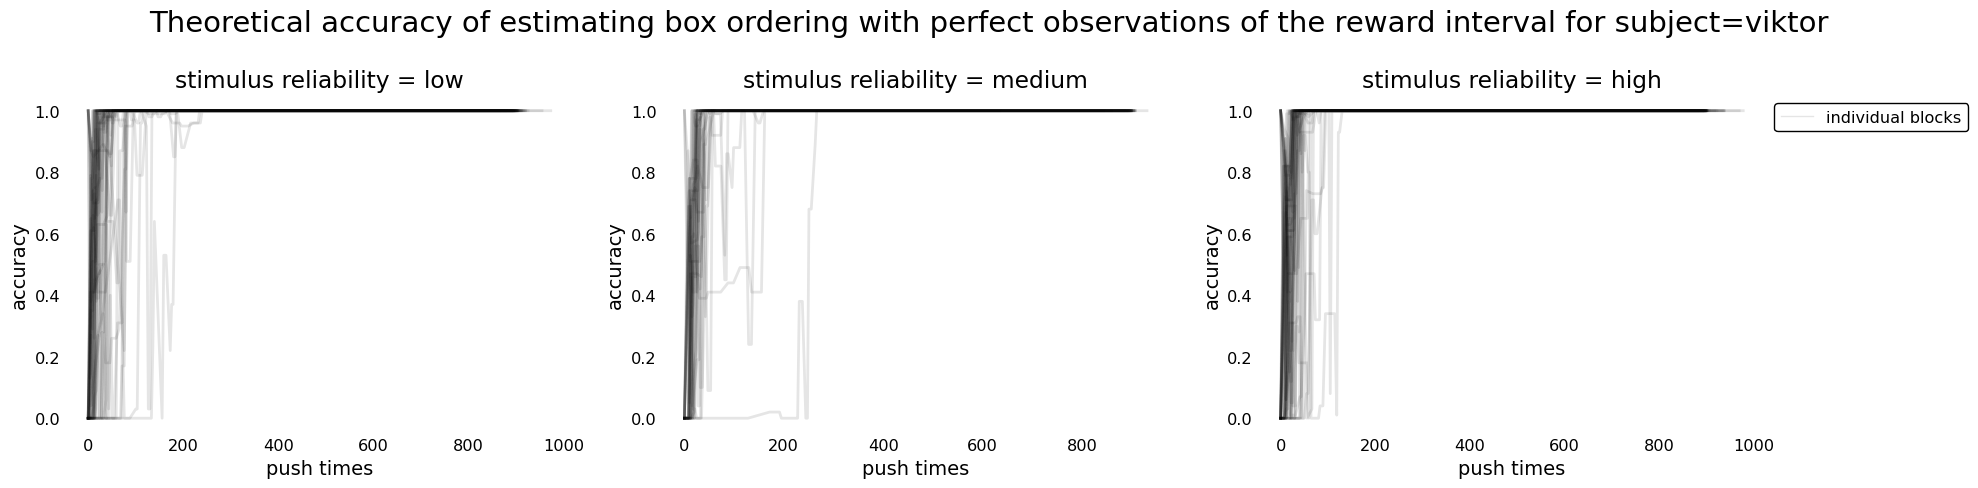

In [ ]:
# Compute beliefs under perfect observations of reward interval
schedule_candidates = np.arange(30) + 1
belief_update = ExactBayesianUpdateOnProbabilities(RewardIntervalLikelihood(), vectorize=True)

def posterior_maker(dataset, block_key, block) -> FactorizedPosterior:
    shape = block.index.unique("shape")[0]
    n_boxes = block["n boxes"].values[0]
    uniform = 1 / len(schedule_candidates) * np.ones(len(schedule_candidates))
    single_box_prior = Probabilities(
        support=PossibleSchedules(schedule=schedule_candidates, shape=shape),
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return FactorizedPosterior(
        n_boxes, new_key, belief_update, prior=single_box_prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_perfect_posterior, posterior_maker = posterior_maker)

# Now compute the accuracy under these beliefs
dataset = dataset.filter(conds = {"shape": 10})
accuracies, _ = dataset.process_blocks(compute_accuracy, beliefs = schedule_beliefs)
plotter.plot_conditions_by_subject(
    plotter.plot_accuracy_across_block, 
    accuracies = accuracies,
    dataset = dataset,
    col_condition = 'stimulus reliability',
    x="push times",
    show_traces=True,
    show_average = False,
    color="black",       
    fig_title='Theoretical accuracy of estimating box ordering with perfect observations of the reward interval' 
);

## What if the subjects know the identities of the schedules just not their ordering?

Now, this framework is only applicable if we assume the subjects 1) treat the boxes as independent and 2) start their inference process from scratch at the start of each block. If the schedules are kept constant over several blocks and merely permuted, then it is conceivable that the subjects eventually get a good handle on the identities of the schedules and only infer the assighment of specific schedules to boxes, not the values of the schedules themselves. In that case, their beliefs are defined over $m!$ permutations, where $m$ is the number of boxes. Analogous to the Fisher information, one can simulate observations under one of the permutations and show how quickly the posterior converges to the right permutation as a function of the number of observations (the result will generalize to the other permutations).

With respect to box ordering, the permutation and continuous beliefs from before carry the same amount of information. Obviously, when it comes the values of the schedules themselves, the permutations don't carry that information since this knowledge is assumed, and that the only knowledge missing is the assignment of schedules to box positions.

<Axes: >

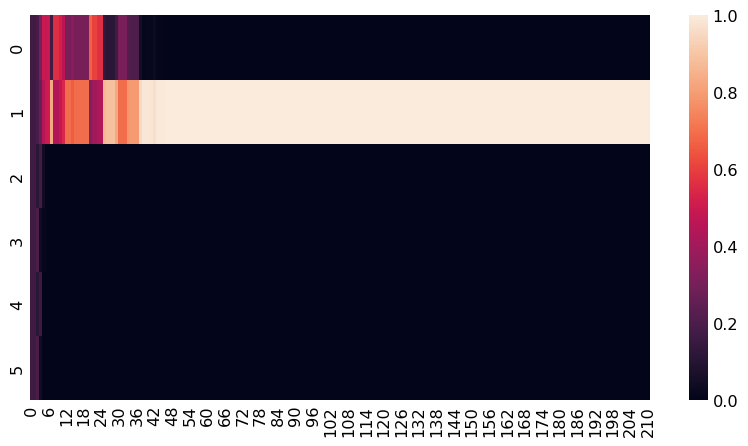

In [ ]:
belief_update = ExactBayesianUpdateOnProbabilities(PermutationLikelihood())

def posterior_maker(dataset, block_key, block) -> Posterior:
    block = block.reset_index()
    shape = block["shape"].iloc[0]
    schedules = sorted(block["assigned schedules"].iloc[0])
    perms = list(permutations(schedules))
    uniform = 1 / len(perms) * np.ones(len(perms))
    prior = Probabilities(
        support= [Permutation(permutation = x, shape = shape) for x in perms],
        probabilities=uniform,
    )
    new_key = dict(block_key)
    new_key["push time"] = 0
    new_key = HashableDict(new_key)
    return Posterior(
        new_key, update = belief_update, prior=prior
    )

schedule_beliefs, _ = dataset.process_blocks(compute_posterior, posterior_maker = posterior_maker)
probs = np.asarray(schedule_beliefs[HashableDict(subject="viktor", session=20230807, block=5)].representation)
sns.heatmap(probs.T)

# Extra: Knowing the shape parameter after a couple blocks of behavior

So far, we have focused on infering the schedule independently of the shape parameter $\alpha$ that also parameterizes the reward interval distribution. Given that this parameter is fixed across boxes and blocks, one might expect that the subjects are capable of inferring the shape parameter with high confidence only after a couple blocks. To materialize this expectation, we can derive the Fisher information to get a theoretical lower bound on the uncertainty as a function of the number of observations the subject makes.

Under the standard parameterization of the Gamma distribution, which uses the scale parameter $\theta:=\frac{\mu}{\alpha}$, the Fisher information matrix for a single perfect observation of reward interval $t_{\text{reward}}$ is:

$$J(\alpha, \theta) =
\begin{bmatrix}
\psi^{(1)}(\alpha) & \frac{1}{\theta}\\
\frac{1}{\theta} & \frac{\alpha}{\theta^2}
\end{bmatrix}
$$

where $\psi^{(1)}$ denotes the trigamma function. We'll omit the censored obserations for now since they will give similar behavior. We visualize how the Cramer-Rao lower bound shrinks with the number of independent observations below:

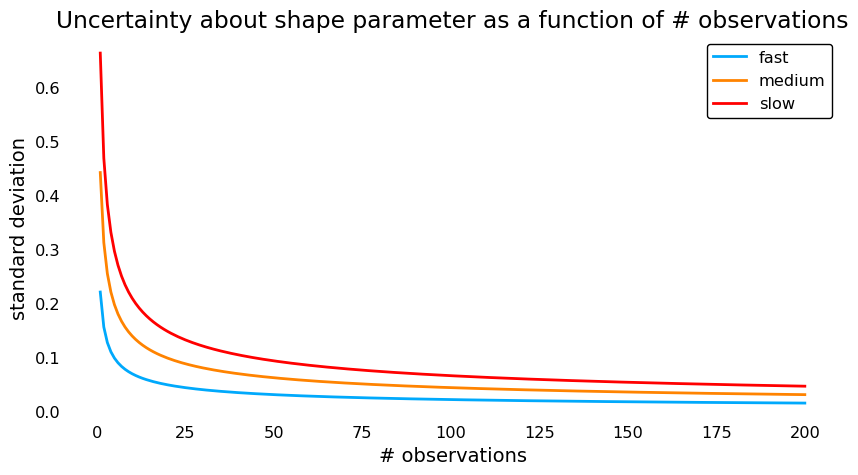

In [57]:
def fisher_info_shape(mu, alpha):
    scale = mu / alpha
    mat = np.array([[polygamma(1, alpha), 1 / scale], [1 / scale, alpha / scale**2]])
    return mat[-1, -1]


# Cramer-Rao lower bound for standard deviation as a function of number of observations
means = [7, 14, 21]
shape = 10
n_obs = np.arange(200) + 1
colors = list(plotter.get_config_value("palette").values())
labels = list(plotter.get_config_value("palette").keys())
for i, mu in enumerate(means):
    fisher_info = fisher_info_shape(mu, shape)
    std_crlb = np.sqrt(1 / (n_obs * fisher_info))
    plt.plot(n_obs, std_crlb, label=labels[i], color=colors[i])

plt.xlabel("# observations")
plt.ylabel("standard deviation")
plt.title("Uncertainty about shape parameter as a function of # observations")
plt.legend()
plt.show()

A typical block of pushes may contain around 200 pushes, so we can safely say that the ideal observer can figure out the shape parameter to a precision of ± 0.1 after just one block of perfect observations about the reward intervals. Also note a curve is shown for each box, but one can imagine pooling observations across all boxes and achieving even lower bounds on the uncertainty.

## Bias

It's perfectly possible that the subjects have a prior about the schedules that could be mismatched to the true schedules. Now, asymptotically the posterior converges to a Gaussian centered on the MLE, with variance equal to 1/fisher information (Laplace approximation), but in the beginning a nontrivial bias may be present that influences behavior. It is also worth thinking about constrained computation-- if the agent prematurely stops updating their posterior due to computational budget, then they may also be biased in their belief about the schedule depending on the nature of their limited observations. Depending on the nature of the bias, the MSE may even be less than that of the unbiased estimator (bias-variance decomposition)

In [ ]:
# Create a ScheduleArray
schedules = PossibleSchedules(schedule=np.array([1.0, 2.0, 3.0, 4.0]), shape=1.0)

# Use as array (for Probabilities)
support_array = np.asarray(schedules)  # Returns: array([1., 2., 3., 4.])
belief = Probabilities(schedules, [0.25, 0.25, 0.25, 0.25])

obs = RewardObservation(is_available=True, time=2.5)
likelihood = GammaLikelihood()
update = ExactBayesianUpdateOnProbabilities(likelihood=likelihood)
update(belief, obs).representation